comparing g and sd across different model types 

created 7/4/2022 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()
from decodedoutputdefs import Precision, training_curve_indv, training_curve_average #class with the compiled definitions

In [2]:
#model comparisons for g and sd 

def removeoutlier(df, sdcut = 100, swapcut = 100):
    new_df = df[df['sd'] < sdcut]
    new_df = new_df[new_df['swap'] < swapcut]
    print("after outliers, {} models".format(len(new_df)))
    
    return new_df

def gsd_acrosstask(base, experiment): 
    df = pd.read_csv(base+experiment+"sir2.csv")
    df = removeoutlier(df)
    models = {"g_sir2": np.mean(df['g']), "sd_sir2": np.mean(df['sd']) }
    
    df = pd.read_csv(base+experiment+"sir2_chunk.csv")
    df = removeoutlier(df)
    models["g_sir2_chunk"] = np.mean(df['g'])
    models["sd_sir2_chunk"]= np.mean(df['sd']) 
    
    df = pd.read_csv(base+experiment+"sir3.csv")
    df = removeoutlier(df)
    models["g_sir3"] = np.mean(df['g'])
    models["sd_sir3"]= np.mean(df['sd']) 
    
    df = pd.read_csv(base+experiment+"sir3_chunk.csv")
    df = removeoutlier(df)
    models["g_sir3_chunk"] = np.mean(df['g'])
    models["sd_sir3_chunk"]= np.mean(df['sd']) 
    
    df = pd.read_csv(base+experiment+"sir4.csv")
    df = removeoutlier(df)
    models["g_sir4"] = np.mean(df['g'])
    models["sd_sir4"]= np.mean(df['sd']) 
    
    df = pd.read_csv(base+experiment+"sir4_chunk.csv")
    df = removeoutlier(df)
    models["g_sir4_chunk"] = np.mean(df['g'])
    models["sd_sir4_chunk"]= np.mean(df['sd']) 
    
    return models

def plot_gsd_acrosstask(base,experiment):
    models = gsd_acrosstask(base,experiment)
    plt.figure()
    x = list(range(1,7))
    y = [models['g_sir2'],models['g_sir2_chunk'],models['g_sir3'],models['g_sir3_chunk'],models['g_sir4'],models['g_sir4_chunk']]
    plt.scatter(x,y)
    plt.xlabel('Model')
    plt.ylabel('Average Guessing Rate')
    plt.title('Guessing Rate Across Tasks')
    lab = ['Sir2', 'Sir2 Chunk', 'Sir3', 'Sir3 Chunk', 'Sir4', 'Sir4 Chunk']
    plt.xticks(x, labels = lab)

    plt.figure()
    x = list(range(1,7))
    y = [models['sd_sir2'],models['sd_sir2_chunk'],models['sd_sir3'],models['sd_sir3_chunk'],models['sd_sir4'],models['sd_sir4_chunk']]
    plt.scatter(x,y)
    plt.xlabel('Model')
    plt.ylabel('Average Standard Deviation')
    plt.title('Standard Deviation Across Tasks')
    lab = ['Sir2', 'Sir2 Chunk', 'Sir3', 'Sir3 Chunk', 'Sir4', 'Sir4 Chunk']
    plt.xticks(x, labels = lab)
    

def gsd_acrosssigma(base,experiments):
    models = {}
    for exp in experiments:
        df = pd.read_csv(base+exp+"sir4.csv")
        df = removeoutlier(df)
        models[exp+"g_sir4"] = np.mean(df['g'])
        models[exp+"sd_sir4"]= np.mean(df['sd']) 

        df = pd.read_csv(base+exp+"sir4_chunk.csv")
        df = removeoutlier(df)
        models[exp+"g_sir4_chunk"] = np.mean(df['g'])
        models[exp+"sd_sir4_chunk"]= np.mean(df['sd']) 
    return models

#def gsd_acrossDAGain(base,experiments):
    
    

In [7]:
df[df["g"]>0.4]

,g,sd,swap,Name
0,0.442156,0.000047,5.158934,model0err.csv
2,0.446558,0.000477,4.544745,model11err.csv
4,0.494983,0.000239,3.197090,model13err.csv
6,0.522297,0.002493,2.748241,model15err.csv
14,0.713468,0.001075,3.624202,model22err.csv
24,0.401183,0.000038,5.101138,model31err.csv
26,0.499811,0.000549,4.686198,model33err.csv
30,0.408395,0.000089,5.340187,model37err.csv
32,0.558999,0.000311,2.599178,model39err.csv
63,0.519249,0.020952,3.817708,model67err.csv


after outliers, 80 models


Text(0.5, 1.0, 'Mean Swap: 5.9903299326337685')

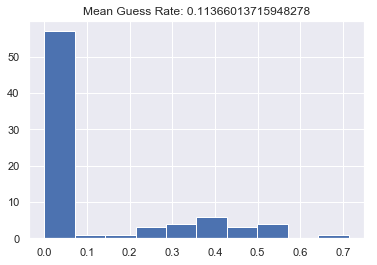

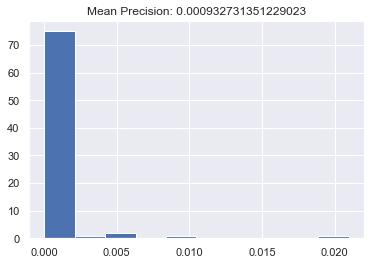

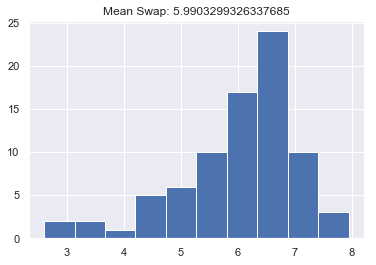

In [3]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'nonresponseswap/'
df = pd.read_csv(base+experiment+"sir2_chunk.csv")
df = removeoutlier(df)
plt.figure()
plt.hist(df['g'])
plt.title('Mean Guess Rate: {}'.format(np.mean(df['g'])))

plt.figure()
plt.hist(df['sd'])
plt.title('Mean Precision: {}'.format(np.mean(df['sd'])))

plt.figure()
plt.hist(df['swap'])
plt.title('Mean Swap: {}'.format(np.mean(df['swap'])))

In [12]:
gcutoff = 0.4
df_good = df[df['g'] <=gcutoff]
model_names = df_good['Name'].values
good_models = {"sir2": model_names}

In [15]:
len(good_models['sir2'])
80-55

25

after outliers, 79 models


Text(0.5, 1.0, 'Mean Swap: 4.630615362144402')

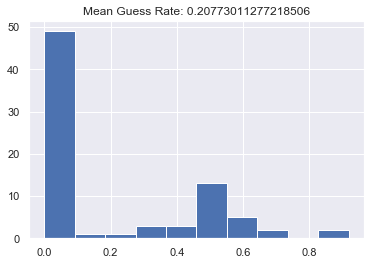

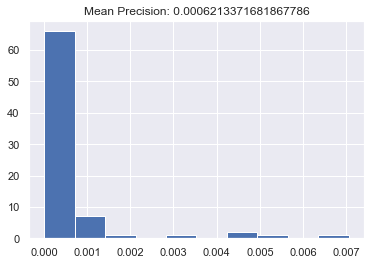

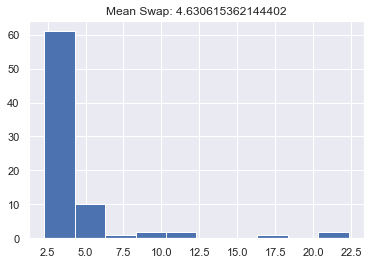

In [8]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'nonresponseswap/'
df = pd.read_csv(base+experiment+"sir2.csv")
df = removeoutlier(df)
plt.figure()
plt.hist(df['g'])
plt.title('Mean Guess Rate: {}'.format(np.mean(df['g'])))

plt.figure()
plt.hist(df['sd'])
plt.title('Mean Precision: {}'.format(np.mean(df['sd'])))

plt.figure()
plt.hist(df['swap'])
plt.title('Mean Swap: {}'.format(np.mean(df['swap'])))

after outliers, 78 models


Text(0.5, 1.0, 'Mean Swap: 4.683825349245014')

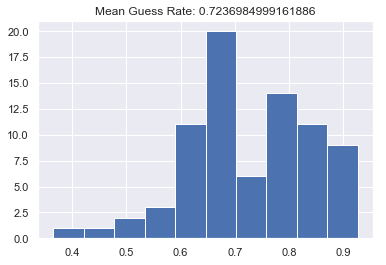

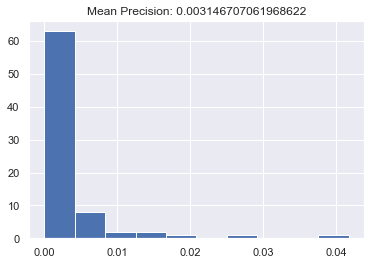

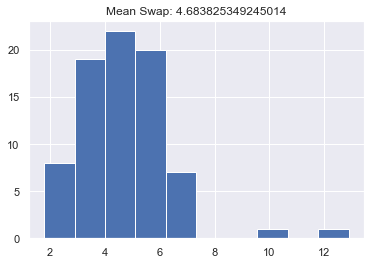

In [12]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'nonresponseswap/'
df = pd.read_csv(base+experiment+"sir3_chunk.csv")
df = removeoutlier(df)
plt.figure()
plt.hist(df['g'])
plt.title('Mean Guess Rate: {}'.format(np.mean(df['g'])))

plt.figure()
plt.hist(df['sd'])
plt.title('Mean Precision: {}'.format(np.mean(df['sd'])))

plt.figure()
plt.hist(df['swap'])
plt.title('Mean Swap: {}'.format(np.mean(df['swap'])))

after outliers, 77 models


Text(0.5, 1.0, 'Mean Swap: 4.993141807287326')

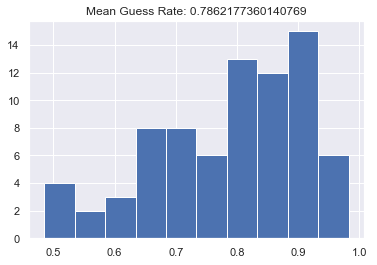

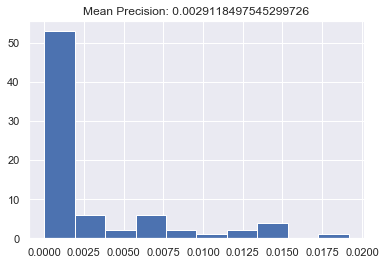

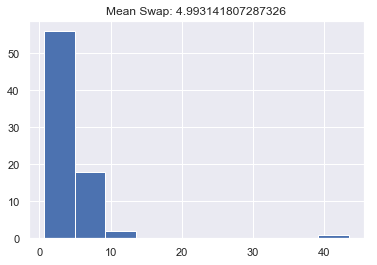

In [13]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'nonresponseswap/'
df = pd.read_csv(base+experiment+"sir3.csv")
df = removeoutlier(df)
plt.figure()
plt.hist(df['g'])
plt.title('Mean Guess Rate: {}'.format(np.mean(df['g'])))

plt.figure()
plt.hist(df['sd'])
plt.title('Mean Precision: {}'.format(np.mean(df['sd'])))

plt.figure()
plt.hist(df['swap'])
plt.title('Mean Swap: {}'.format(np.mean(df['swap'])))

after outliers, 78 models


Text(0.5, 1.0, 'Mean Swap: 4.840723364600079')

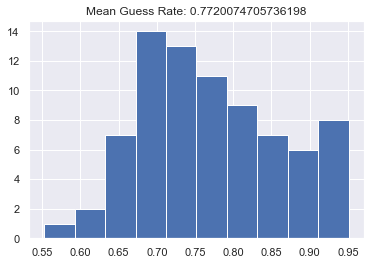

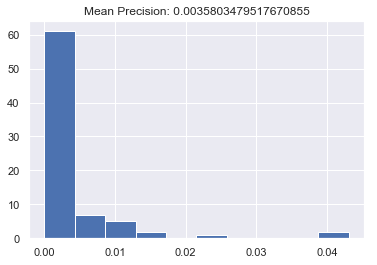

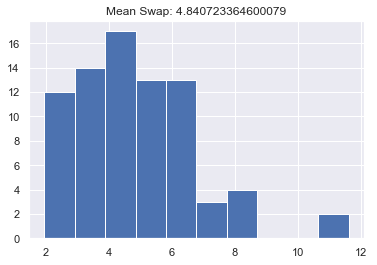

In [11]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'nonresponseswap/'
df = pd.read_csv(base+experiment+"sir4_chunk.csv")
df = removeoutlier(df)
plt.figure()
plt.hist(df['g'])
plt.title('Mean Guess Rate: {}'.format(np.mean(df['g'])))

plt.figure()
plt.hist(df['sd'])
plt.title('Mean Precision: {}'.format(np.mean(df['sd'])))

plt.figure()
plt.hist(df['swap'])
plt.title('Mean Swap: {}'.format(np.mean(df['swap'])))

In [8]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'nonresponseswap/'
df = pd.read_csv(base+experiment+"sir4.csv")
df = removeoutlier(df)

after outliers, 76 models


Text(0.5, 1.0, 'Mean Swap: 5.511205285471908')

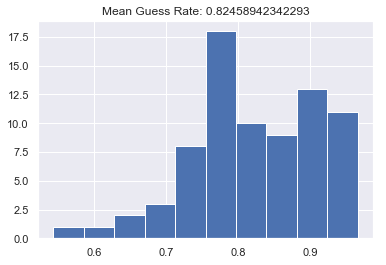

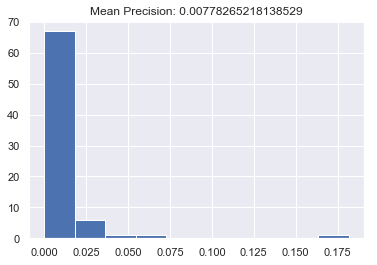

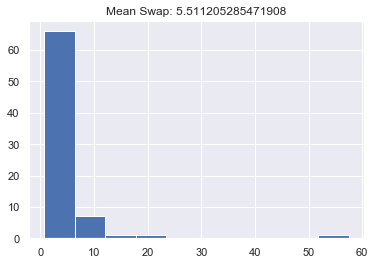

In [10]:
plt.figure()
plt.hist(df['g'])
plt.title('Mean Guess Rate: {}'.format(np.mean(df['g'])))

plt.figure()
plt.hist(df['sd'])
plt.title('Mean Precision: {}'.format(np.mean(df['sd'])))

plt.figure()
plt.hist(df['swap'])
plt.title('Mean Swap: {}'.format(np.mean(df['swap'])))

In [4]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'swap/'
df = pd.read_csv(base+experiment+"sir4.csv")

In [11]:
df.head()

,g,sd,swap,Name
0,0.873725,0.000905,4.209217,model0err.csv
1,0.799881,0.002435,5.054146,model10err.csv
2,0.889805,0.006267,3.394319,model11err.csv
3,0.801157,0.000264,4.481313,model12err.csv
4,0.701831,0.000449,4.039965,model13err.csv


Text(0.5, 1.0, 'Mean Swap: 10.846728688388877')

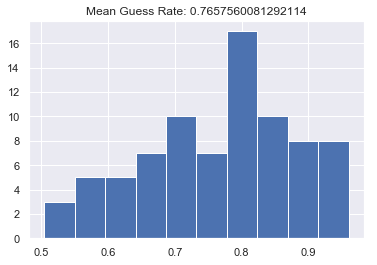

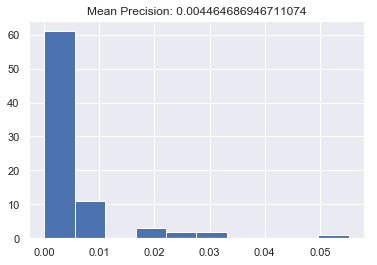

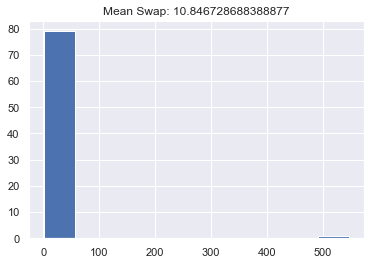

In [12]:
plt.figure()
plt.hist(df['g'])
plt.title('Mean Guess Rate: {}'.format(np.mean(df['g'])))

plt.figure()
plt.hist(df['sd'])
plt.title('Mean Precision: {}'.format(np.mean(df['sd'])))

plt.figure()
plt.hist(df['swap'])
plt.title('Mean Swap: {}'.format(np.mean(df['swap'])))

after outliers, 80 models
after outliers, 80 models
after outliers, 80 models
after outliers, 80 models
after outliers, 80 models
after outliers, 80 models


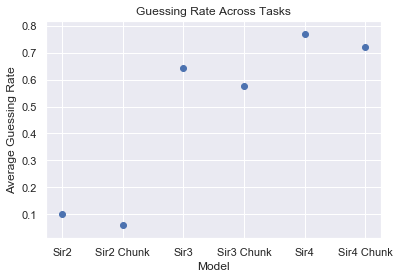

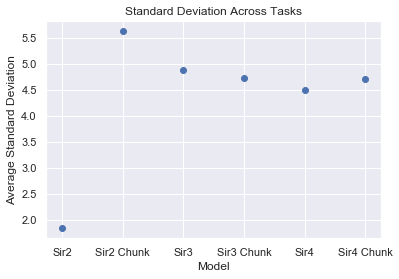

In [3]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'VP/'
plot_gsd_acrosstask(base,experiment)

In [101]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
models = gsd_acrosssigma(base, ['sigma08/','sigma12/', ''])

after outliers, 79 models
after outliers, 80 models
after outliers, 79 models
after outliers, 78 models
after outliers, 80 models
after outliers, 80 models


In [102]:
models

{'sigma08/g_sir4': 0.751740553681922,
 'sigma08/sd_sir4': 4.462868606423546,
 'sigma08/g_sir4_chunk': 0.7349962051549892,
 'sigma08/sd_sir4_chunk': 3.126482393677545,
 'sigma12/g_sir4': 0.7821767484231337,
 'sigma12/sd_sir4': 3.6399128737427597,
 'sigma12/g_sir4_chunk': 0.7133911472748234,
 'sigma12/sd_sir4_chunk': 4.569376323984805,
 'g_sir4': 0.776616446485824,
 'sd_sir4': 4.629294547358422,
 'g_sir4_chunk': 0.7364319352541162,
 'sd_sir4_chunk': 4.9195780965411755}

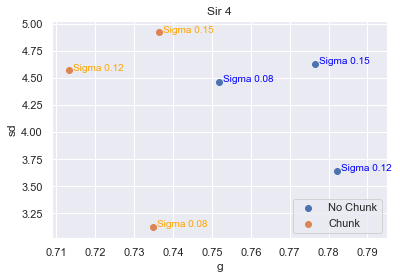

In [108]:
plt.figure()
lab = ['Sigma 0.08','Sigma 0.12', 'Sigma 0.15']
g = [models['sigma08/g_sir4'],models['sigma12/g_sir4'],models['g_sir4']]
sd = [models['sigma08/sd_sir4'],models['sigma12/sd_sir4'],models['sd_sir4']]
plt.scatter(g,sd)
for i in range(len(sd)):
    plt.text(g[i]+0.001, sd[i]+0.001,lab[i], color='blue')
g = [models['sigma08/g_sir4_chunk'],models['sigma12/g_sir4_chunk'],models['g_sir4_chunk']]
sd = [models['sigma08/sd_sir4_chunk'],models['sigma12/sd_sir4_chunk'],models['sd_sir4_chunk']]
plt.scatter(g,sd)
for i in range(len(sd)):
    plt.text(g[i]+0.001, sd[i]+0.001,lab[i], color='orange')
plt.legend(['No Chunk', 'Chunk'], loc = 'lower right')
plt.title('Sir 4')
plt.xlabel('g')
plt.ylabel('sd')

plt.show()

In [109]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'sigma08/'
models = gsd_acrosstask(base,experiment)

after outliers, 80 models
after outliers, 80 models
after outliers, 78 models
after outliers, 80 models
after outliers, 79 models
after outliers, 80 models


([<matplotlib.axis.XTick at 0x18962d1ad30>,
 <a list of 6 Text xticklabel objects>)

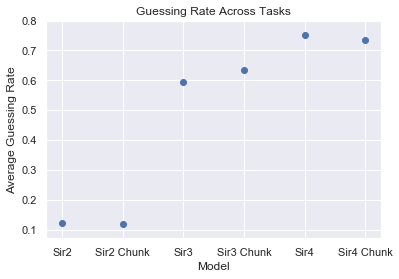

In [110]:
    plt.figure()
    x = list(range(1,7))
    y = [models['g_sir2'],models['g_sir2_chunk'],models['g_sir3'],models['g_sir3_chunk'],models['g_sir4'],models['g_sir4_chunk']]
    plt.scatter(x,y)
    plt.xlabel('Model')
    plt.ylabel('Average Guessing Rate')
    plt.title('Guessing Rate Across Tasks')
    lab = ['Sir2', 'Sir2 Chunk', 'Sir3', 'Sir3 Chunk', 'Sir4', 'Sir4 Chunk']
    plt.xticks(x, labels = lab)


([<matplotlib.axis.XTick at 0x18963f2ab00>,
 <a list of 6 Text xticklabel objects>)

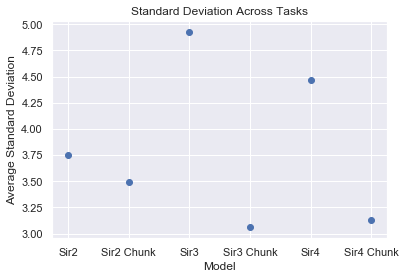

In [111]:
    plt.figure()
    x = list(range(1,7))
    y = [models['sd_sir2'],models['sd_sir2_chunk'],models['sd_sir3'],models['sd_sir3_chunk'],models['sd_sir4'],models['sd_sir4_chunk']]
    plt.scatter(x,y)
    plt.xlabel('Model')
    plt.ylabel('Average Standard Deviation')
    plt.title('Standard Deviation Across Tasks')
    lab = ['Sir2', 'Sir2 Chunk', 'Sir3', 'Sir3 Chunk', 'Sir4', 'Sir4 Chunk']
    plt.xticks(x, labels = lab)

Text(0, 0.5, 'SD')

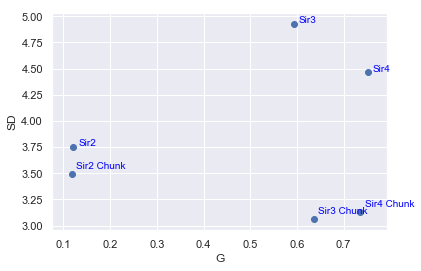

In [112]:
plt.figure()
sd = [models['sd_sir2'],models['sd_sir2_chunk'],models['sd_sir3'],models['sd_sir3_chunk'],models['sd_sir4'],models['sd_sir4_chunk']]
g = [models['g_sir2'],models['g_sir2_chunk'],models['g_sir3'],models['g_sir3_chunk'],models['g_sir4'],models['g_sir4_chunk']]
plt.scatter(g, sd)
lab = ['Sir2', 'Sir2 Chunk', 'Sir3', 'Sir3 Chunk', 'Sir4', 'Sir4 Chunk']
for i in range(len(sd)):
    if np.mod(i,2) == 0:
        plt.text(g[i]+0.01, sd[i]+0.01,lab[i], color='blue')
    else:
        plt.text(g[i]+0.01, sd[i]+0.05,lab[i], color='blue')
plt.xlabel('G')
plt.ylabel('SD')